Other Metrics:
--------------------------------------------------

PREDRNN_HKO7_SIGMOID:
MAE: 0.0304
MSE: 0.0089
SSIM: 0.7459
PSNR: 22.6853

SIMVP_HKO7_SIGMOID:
MAE: 0.0327
MSE: 0.0094
SSIM: 0.6951
PSNR: 22.3534

PREDRNN_HKO7:
MAE: 0.0288
MSE: 0.0073
SSIM: 0.7391
PSNR: 23.7671

CONVLSTM_HKO7:
MAE: 0.0311
MSE: 0.0072
SSIM: 0.6929
PSNR: 23.7162

SIMVP_HKO7:
MAE: 0.0305
MSE: 0.0070
SSIM: 0.6993
PSNR: 23.7969

CONVLSTM_HKO7_SIGMOID:
MAE: 0.0324
MSE: 0.0095
SSIM: 0.7360
PSNR: 22.4542


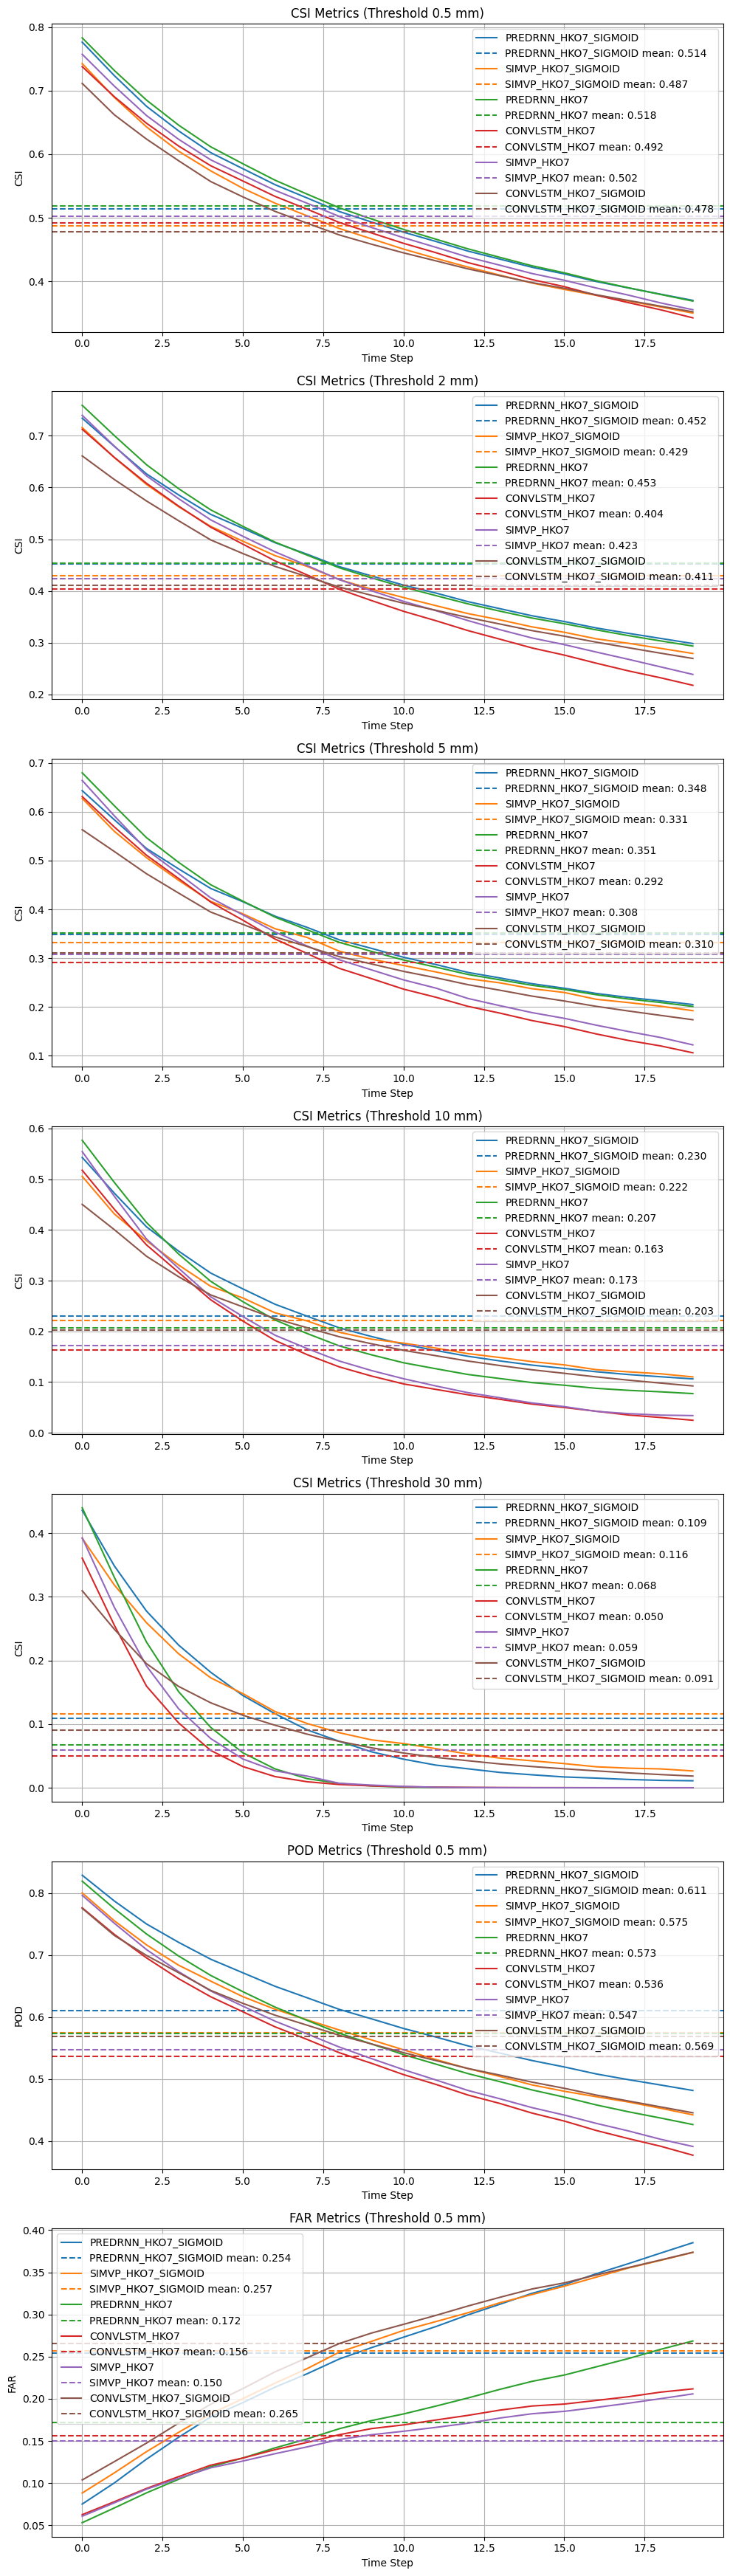

In [5]:
import json
models = {"CONVLSTM_HKO7", "CONVLSTM_HKO7_SIGMOID", "SIMVP_HKO7", "SIMVP_HKO7_SIGMOID", "PREDRNN_HKO7", "PREDRNN_HKO7_SIGMOID"}
# models = {"CONVLSTM_HKO7", "CONVLSTM_HKO7_SIGMOID", "SIMVP_HKO7", "SIMVP_HKO7_SIGMOID"}

results = {}
for model in models:
    with open(f'/workspace_bk/piyush/results/facl/{model}/{model}_results.json', 'r') as f:
        results[model] = json.load(f)
import matplotlib.pyplot as plt
import numpy as np

# Print other metrics (MAE, MSE, SSIM, PSNR)
print("Other Metrics:")
print("-" * 50)
for model in models:
    print(f"\n{model}:")
    print(f"MAE: {results[model]['mae']:.4f}")
    print(f"MSE: {results[model]['mse']:.4f}")
    print(f"SSIM: {results[model]['ssim']:.4f}")
    print(f"PSNR: {results[model]['psnr']:.4f}")

# Create figure with subplots for each CSI threshold
thresholds = [84, 117, 140, 158, 185]
threshold_labels = ['0.5 mm', '2 mm', '5 mm', '10 mm', '30 mm']
fig, axes = plt.subplots(7, 1, figsize=(10, 35))
# fig.suptitle('Evaluation Metrics', fontsize=16)

# Plot CSI metrics for each threshold
for i, (threshold, label) in enumerate(zip(thresholds, threshold_labels)):
    metric = f'csi-{threshold}'
    for model in models:
        line = axes[i].plot(results[model][metric], label=f'{model}')
        mean_val = np.mean(results[model][metric])
        axes[i].axhline(y=mean_val, color=line[0].get_color(), linestyle='--',
                       label=f'{model} mean: {mean_val:.3f}')
    axes[i].set_title(f'CSI Metrics (Threshold {label})')
    axes[i].set_xlabel('Time Step')
    axes[i].set_ylabel('CSI')
    axes[i].legend()
    axes[i].grid(True)

# Plot POD
for model in models:
    line = axes[5].plot(results[model]['pod-84'], label=f'{model}')
    mean_val = np.mean(results[model]['pod-84'])
    axes[5].axhline(y=mean_val, color=line[0].get_color(), linestyle='--',
                    label=f'{model} mean: {mean_val:.3f}')
axes[5].set_title('POD Metrics (Threshold 0.5 mm)')
axes[5].set_xlabel('Time Step')
axes[5].set_ylabel('POD')
axes[5].legend()
axes[5].grid(True)

# Plot FAR
for model in models:
    line = axes[6].plot(results[model]['far-84'], label=f'{model}')
    mean_val = np.mean(results[model]['far-84'])
    axes[6].axhline(y=mean_val, color=line[0].get_color(), linestyle='--',
                    label=f'{model} mean: {mean_val:.3f}')
axes[6].set_title('FAR Metrics (Threshold 0.5 mm)')
axes[6].set_xlabel('Time Step')
axes[6].set_ylabel('FAR')
axes[6].legend()
axes[6].grid(True)

plt.tight_layout()
plt.show()

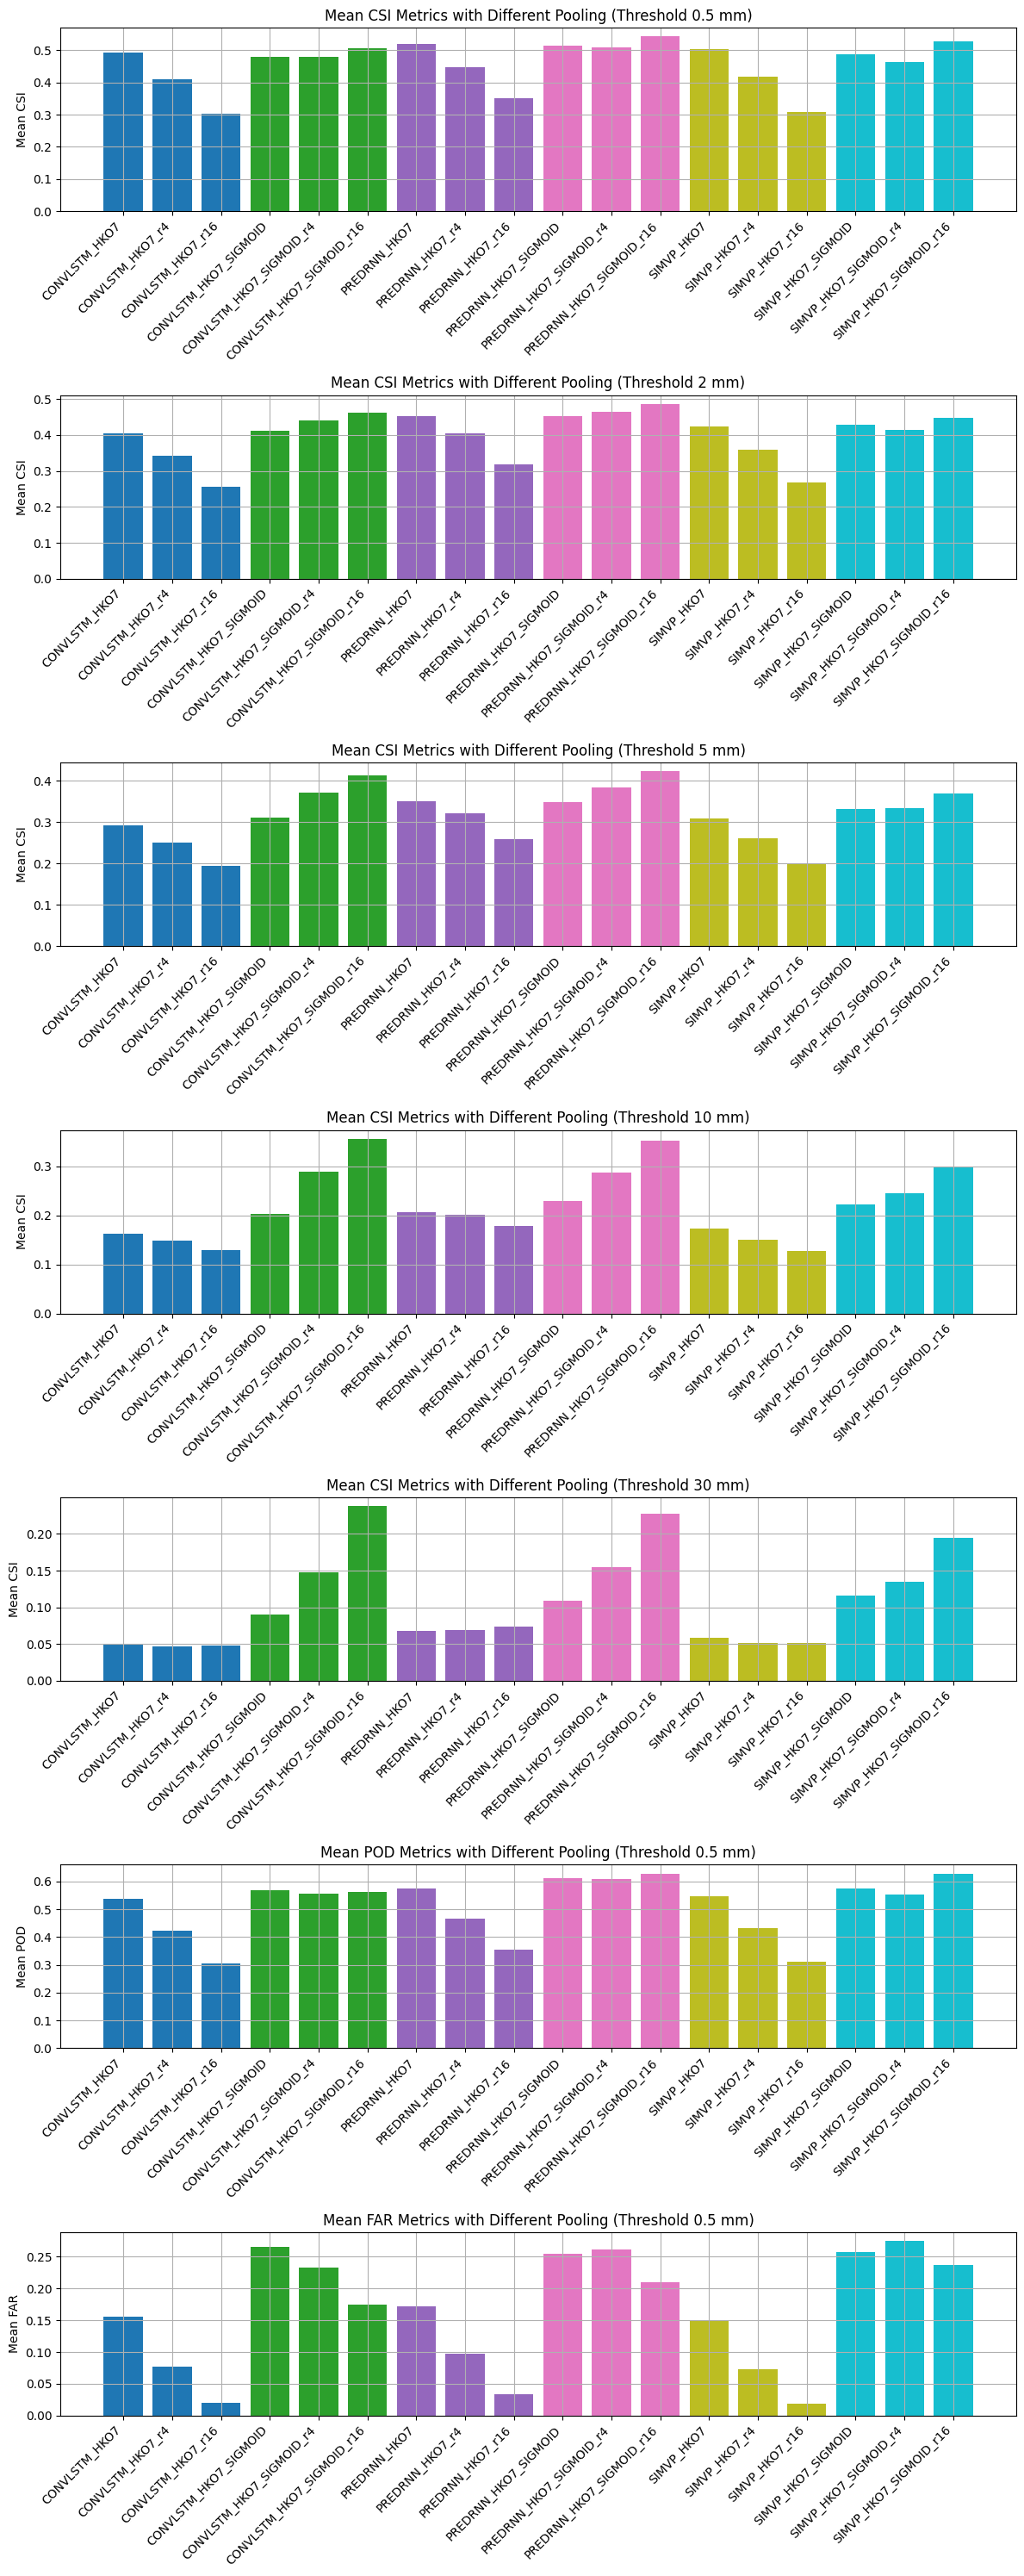

In [14]:
# Read results for different pooling radii
radii = [1, 4, 16]  # 1 is the original results without pooling
results_pooled = {}
import os

for radius in radii:
    radius_suffix = '' if radius == 1 else f'_radius{radius}'
    for model in models:
        result_path = f'/workspace_bk/piyush/results/facl/{model}/{model}{radius_suffix}_results.json'
        if os.path.exists(result_path):
            with open(result_path, 'r') as f:
                if radius == 1:
                    results_pooled[f'{model}'] = json.load(f)
                else:
                    results_pooled[f'{model}_r{radius}'] = json.load(f)

# Group models with radius and sort models based on name
model_groups = {}
for model_name in results_pooled.keys():
    model, radius = model_name.split('_r') if '_r' in model_name else (model_name, 1)
    if model not in model_groups:
        model_groups[model] = {}
    model_groups[model][int(radius)] = model_name

# Sort models based on name
model_groups = {model: {radius: model_groups[model][radius] for radius in sorted(model_groups[model])} for model in sorted(model_groups)}

# Create figure with subplots for mean values as bar charts
thresholds = [84, 117, 140, 158, 185]
threshold_labels = ['0.5 mm', '2 mm', '5 mm', '10 mm', '30 mm']
fig, axes = plt.subplots(7, 1, figsize=(12, 30))

# Plot mean CSI metrics for each threshold as bars
for i, (threshold, label) in enumerate(zip(thresholds, threshold_labels)):
    metric = f'csi-{threshold}'
    model_names = []
    mean_values = []
    colors = plt.cm.get_cmap('tab10', len(model_groups))

    offset = 0
    for j, (model, radius_group) in enumerate(model_groups.items()):
        for radius, model_name in radius_group.items():
            model_names.append(model_name)
            mean_values.append(np.mean(results_pooled[model_name][metric]))
            axes[i].bar(offset, np.mean(results_pooled[model_name][metric]), color=colors(j))
            offset += 1

    x = np.arange(len(model_names))
    axes[i].set_xticks(x)  
    axes[i].set_xticklabels(model_names, rotation=45, ha='right')  
    axes[i].set_title(f'Mean CSI Metrics with Different Pooling (Threshold {label})')
    axes[i].set_ylabel('Mean CSI')
    axes[i].grid(True)

# Plot mean POD as bars
model_names = []
mean_values = []
offset = 0
for j, (model, radius_group) in enumerate(model_groups.items()):
    for radius, model_name in radius_group.items():
        model_names.append(model_name)
        mean_values.append(np.mean(results_pooled[model_name]['pod-84']))
        axes[5].bar(offset, np.mean(results_pooled[model_name]['pod-84']), color=plt.cm.get_cmap('tab10', len(model_groups))(j))
        offset += 1

x = np.arange(len(model_names))
axes[5].set_xticks(x)  
axes[5].set_xticklabels(model_names, rotation=45, ha='right')  
axes[5].set_title('Mean POD Metrics with Different Pooling (Threshold 0.5 mm)')
axes[5].set_ylabel('Mean POD')
axes[5].grid(True)

# Plot mean FAR as bars
model_names = []
mean_values = []
offset = 0
for j, (model, radius_group) in enumerate(model_groups.items()):
    for radius, model_name in radius_group.items():
        model_names.append(model_name)
        mean_values.append(np.mean(results_pooled[model_name]['far-84']))
        axes[6].bar(offset, np.mean(results_pooled[model_name]['far-84']), color=plt.cm.get_cmap('tab10', len(model_groups))(j))
        offset += 1

x = np.arange(len(model_names))
axes[6].set_xticks(x)  
axes[6].set_xticklabels(model_names, rotation=45, ha='right')  
axes[6].set_title('Mean FAR Metrics with Different Pooling (Threshold 0.5 mm)')
axes[6].set_ylabel('Mean FAR')
axes[6].grid(True)

plt.tight_layout()
plt.show()
